# Final Project: Integrated Data Analysis Project
## Subject: Homelessness

The goal is to analyze homeless shelters across the U.S. to identify areas and times that need additional resources and shelter development, along with the costs of such development. 

## Importing Libraries

In [18]:
import pandas as pd
from matplotlib import pyplot as plt 

## Data Sourcing

I found this dataset by searching for homelessness datasets in Kaggle:

https://www.kaggle.com/datasets/shamimhasan8/homelessness-and-shelter-data

There are various websites that show prices of available land in certain regions. This dataset provides a good aggregation of land prices across the entire U.S:

https://www.aei.org/housing/land-price-indicators/


In [3]:
shelters = pd.read_csv("homelessness_shelter_data.csv")
res_land_price = pd.read_excel("AEI_adjusted-Land-Data-2024-1.xlsx", sheet_name="CBSA")

## Data Preparation and Integration
### Exploratory Data Analysis
#### Overview of the Dataframes' Features

In [4]:
shelters.head()

,id,date,shelter_name,city,state,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,male_percentage,female_percentage,season,notes
0,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,43,57,Spring,High demand
1,2,2023-08-01,Safe Haven,Dallas,TX,128,117,11,91.4,58,45,55,Summer,No issues reported
2,3,2025-04-27,Second Chance,San Jose,CA,190,144,46,75.8,56,52,48,Summer,Excellent condition
3,4,2024-10-05,Harbor Home,San Jose,CA,115,7,108,6.1,63,48,52,Autumn,Needs maintenance
4,5,2024-09-15,Harbor Home,San Antonio,TX,155,65,90,41.9,21,48,52,Summer,No issues reported


In [5]:
res_land_price.head()

,CBSA,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA)
0,"Aberdeen, SD",10100,2012,72000,21800,0.122,1.000
1,"Aberdeen, SD",10100,2013,75900,23000,0.125,1.025
2,"Aberdeen, SD",10100,2014,62300,18900,0.101,1.037
3,"Aberdeen, SD",10100,2015,65100,19700,0.105,1.050
4,"Aberdeen, SD",10100,2016,98400,29800,0.150,1.105


CBSA stands for core-based statistical area. It is roughly equivalent to major cities. I plan to integrate shelters and land price on this feature. I will split the CBSA values into City and State to do so. 

https://en.wikipedia.org/wiki/List_of_core-based_statistical_areas

https://www.bls.gov/tus/dictionaries/gtcbsa_gtco_aug_2015.pdf

#### Checking for Missing Values

In [6]:
shelters.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1000 non-null   int64  
 1   date               1000 non-null   str    
 2   shelter_name       1000 non-null   str    
 3   city               1000 non-null   str    
 4   state              1000 non-null   str    
 5   total_capacity     1000 non-null   int64  
 6   occupied_beds      1000 non-null   int64  
 7   available_beds     1000 non-null   int64  
 8   occupancy_rate     1000 non-null   float64
 9   average_age        1000 non-null   int64  
 10  male_percentage    1000 non-null   int64  
 11  female_percentage  1000 non-null   int64  
 12  season             1000 non-null   str    
 13  notes              913 non-null    str    
dtypes: float64(1), int64(7), str(6)
memory usage: 109.5 KB


All features of the shelters dataframe have non-null values except notes. I don't plan on analyzing the notes feature, so we can ignore that missing notes data. If I decide to recommend sentiment analysis of the notes for future research, then those missing values would need to be addressed.  

In [14]:
res_land_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 11206 entries, 0 to 11205
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   CBSA                                     11206 non-null  str    
 1   CBSA Code                                11206 non-null  int64  
 2   Year                                     11206 non-null  int64  
 3   Land Value (Per Acre, As-Is)             11206 non-null  int64  
 4   Land Value (1/4 Acre Lot, Standardized)  11206 non-null  int64  
 5   Land Share of Property Value             11206 non-null  float64
 6   Home Price Appreciation (HPA)            11206 non-null  float64
dtypes: float64(2), int64(4), str(1)
memory usage: 613.0 KB


All features of the residential land price dataframe have non-null values.

#### Overview of the Data Distributions

In [6]:
shelters.describe()

,id,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,male_percentage,female_percentage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,179.123000,91.874000,87.249000,51.214700,42.037000,54.634000,45.366000
std,288.819436,73.419195,67.068937,65.531224,28.880331,13.768122,8.797468,8.797468
min,1.000000,50.000000,0.000000,0.000000,0.000000,18.000000,40.000000,30.000000
25%,250.750000,115.000000,38.000000,35.000000,26.775000,30.000000,47.000000,38.000000
50%,500.500000,182.000000,76.000000,71.000000,51.850000,42.000000,55.000000,45.000000
75%,750.250000,243.000000,136.000000,128.250000,76.800000,54.000000,62.000000,53.000000
max,1000.000000,300.000000,294.000000,296.000000,100.000000,65.000000,70.000000,60.000000


In [15]:
res_land_price.describe()

,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA)
count,11206.000000,11206.000000,1.120600e+04,1.120600e+04,11206.000000,11206.000000
mean,29862.737819,2018.000000,2.538533e+05,8.811862e+04,0.315959,1.441001
std,11406.387273,3.741824,5.216632e+05,1.272137e+05,0.142970,0.449742
min,10100.000000,2012.000000,-9.230000e+04,-2.920000e+04,-0.298000,0.688000
25%,20020.000000,2015.000000,6.140000e+04,2.750000e+04,0.208000,1.086000
50%,29920.000000,2018.000000,1.182500e+05,5.010000e+04,0.296000,1.288000
75%,39780.000000,2021.000000,2.441000e+05,9.577500e+04,0.411000,1.693000
max,49820.000000,2024.000000,9.941600e+06,1.927200e+06,0.838000,3.555000


### Integrating the Data
First, preparing the res_land_price df for merging the tables:

In [7]:
res_land_price[['City', 'State']] = res_land_price['CBSA'].str.split(', ', expand=True)

In [8]:
res_land_price.head()

,CBSA,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA),City,State
0,"Aberdeen, SD",10100,2012,72000,21800,0.122,1.000,Aberdeen,SD
1,"Aberdeen, SD",10100,2013,75900,23000,0.125,1.025,Aberdeen,SD
2,"Aberdeen, SD",10100,2014,62300,18900,0.101,1.037,Aberdeen,SD
3,"Aberdeen, SD",10100,2015,65100,19700,0.105,1.050,Aberdeen,SD
4,"Aberdeen, SD",10100,2016,98400,29800,0.150,1.105,Aberdeen,SD


In [10]:
shelters.rename(columns={'city': 'City'}, inplace=True)

In [11]:
shelter_land_price = pd.merge(shelters, res_land_price, how='inner', on='City')

In [13]:
res_land_price.drop('State', axis=1, inplace=True)
res_land_price.drop('CBSA', axis=1, inplace=True)

### Quick Look at the Integrated Data

Let's explore briefly what kind of patterns are in the integrated dataset.

In [14]:
shelter_land_price.head()

,id,date,shelter_name,City,state,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,...,season,notes,CBSA,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA),State
0,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,...,Spring,High demand,"Dallas, TX",19100,2012,165200,45200,0.274,1.000,TX
1,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,...,Spring,High demand,"Dallas, TX",19100,2013,195900,53600,0.303,1.073,TX
2,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,...,Spring,High demand,"Dallas, TX",19100,2014,228500,62500,0.330,1.149,TX
3,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,...,Spring,High demand,"Dallas, TX",19100,2015,284700,77900,0.376,1.255,TX
4,1,2023-10-05,Sunrise Shelter,Dallas,TX,85,62,23,72.9,19,...,Spring,High demand,"Dallas, TX",19100,2016,352800,96500,0.428,1.366,TX


In [32]:
shelter_land_price.columns

Index(['id', 'date', 'shelter_name', 'City', 'state', 'total_capacity',
       'occupied_beds', 'available_beds', 'occupancy_rate', 'average_age',
       'male_percentage', 'female_percentage', 'season', 'notes', 'CBSA',
       'CBSA Code', 'Year', 'Land Value (Per Acre, As-Is)',
       'Land Value (1/4 Acre Lot, Standardized)',
       'Land Share of Property Value', 'Home Price Appreciation (HPA)',
       'State'],
      dtype='str')

In [15]:
shelter_land_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 13000 entries, 0 to 12999
Data columns (total 22 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       13000 non-null  int64  
 1   date                                     13000 non-null  str    
 2   shelter_name                             13000 non-null  str    
 3   City                                     13000 non-null  str    
 4   state                                    13000 non-null  str    
 5   total_capacity                           13000 non-null  int64  
 6   occupied_beds                            13000 non-null  int64  
 7   available_beds                           13000 non-null  int64  
 8   occupancy_rate                           13000 non-null  float64
 9   average_age                              13000 non-null  int64  
 10  male_percentage                          13000 non-null  

In [16]:
shelter_land_price.describe()

,id,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,male_percentage,female_percentage,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA)
count,13000.000000,13000.000000,13000.000000,13000.00000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,13000.000000,1.300000e+04,1.300000e+04,13000.000000,13000.000000
mean,500.500000,179.123000,91.874000,87.24900,51.214700,42.037000,54.634000,45.366000,32563.080000,2018.000000,1.808040e+06,4.021773e+05,0.495640,1.639999
std,288.686094,73.385299,67.037973,65.50097,28.866998,13.761766,8.793406,8.793406,9033.388578,3.741801,2.052428e+06,4.259935e+05,0.154481,0.528874
min,1.000000,50.000000,0.000000,0.00000,0.000000,18.000000,40.000000,30.000000,16980.000000,2012.000000,1.195000e+05,3.170000e+04,0.211000,1.000000
25%,250.750000,115.000000,38.000000,35.00000,26.775000,30.000000,47.000000,38.000000,26420.000000,2015.000000,4.125000e+05,1.029000e+05,0.382000,1.206000
50%,500.500000,182.000000,76.000000,71.00000,51.850000,42.000000,55.000000,45.000000,35620.000000,2018.000000,8.154000e+05,2.036000e+05,0.469000,1.485000
75%,750.250000,243.000000,136.000000,128.25000,76.800000,54.000000,62.000000,53.000000,41700.000000,2021.000000,2.693000e+06,5.781000e+05,0.607000,1.946000
max,1000.000000,300.000000,294.000000,296.00000,100.000000,65.000000,70.000000,60.000000,41940.000000,2024.000000,9.489900e+06,1.927200e+06,0.788000,3.145000


array([[<Axes: title={'center': 'Land Value (Per Acre, As-Is)'}>]],
      dtype=object)

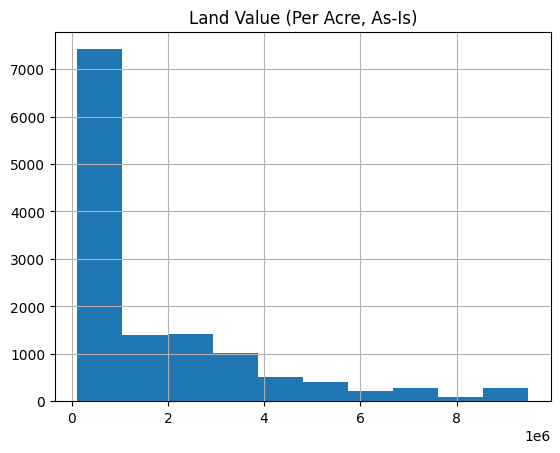

In [19]:
shelter_land_price.hist(column="Land Value (Per Acre, As-Is)")

<Axes: xlabel='Land Value (Per Acre, As-Is)', ylabel='occupancy_rate'>

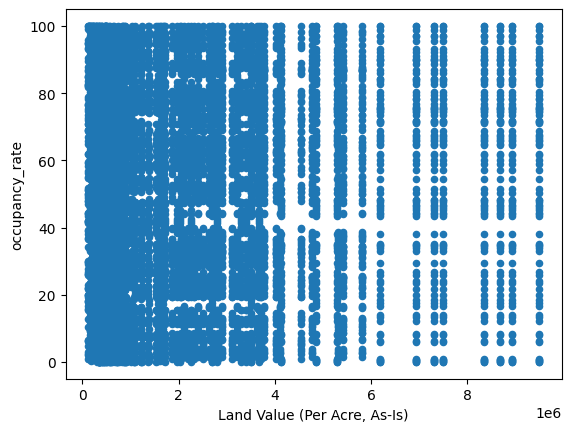

In [25]:
shelter_land_price.plot.scatter("Land Value (Per Acre, As-Is)", "occupancy_rate")

In [23]:
shelter_land_price.loc[shelter_land_price['Land Value (Per Acre, As-Is)'] == 9.489900e+06]

,id,date,shelter_name,City,state,total_capacity,occupied_beds,available_beds,occupancy_rate,average_age,...,season,notes,CBSA,CBSA Code,Year,"Land Value (Per Acre, As-Is)","Land Value (1/4 Acre Lot, Standardized)",Land Share of Property Value,Home Price Appreciation (HPA),State
38,3,2025-04-27,Second Chance,San Jose,CA,190,144,46,75.8,56,...,Summer,Excellent condition,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
51,4,2024-10-05,Harbor Home,San Jose,CA,115,7,108,6.1,63,...,Autumn,Needs maintenance,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
77,6,2023-09-29,Harbor Home,San Jose,CA,81,61,20,75.3,41,...,Autumn,No issues reported,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
298,23,2024-06-08,HomeSafe,San Jose,CA,271,271,0,100.0,30,...,Autumn,Recently renovated,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
376,29,2025-02-07,Recovery Residence,San Jose,CA,91,15,76,16.5,62,...,Autumn,NaN,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12401,954,2025-07-08,Second Chance,San Jose,CA,210,124,86,59.0,36,...,Spring,Staff shortage,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
12479,960,2023-11-19,Shelter Plus,San Jose,CA,132,126,6,95.5,21,...,Summer,High demand,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
12921,994,2024-11-30,Harbor Home,San Jose,CA,265,121,144,45.7,41,...,Summer,Staff shortage,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA
12947,996,2023-11-14,New Beginnings,San Jose,CA,205,199,6,97.1,45,...,Winter,Recently renovated,"San Jose, CA",41940,2024,9489900,1927200,0.782,2.734,CA


In [30]:
winter_2024 = shelter_land_price.loc[((shelter_land_price['season'] == 'Winter') & (shelter_land_price['Year'] == 2024))]

<Axes: xlabel='Land Value (Per Acre, As-Is)', ylabel='occupancy_rate'>

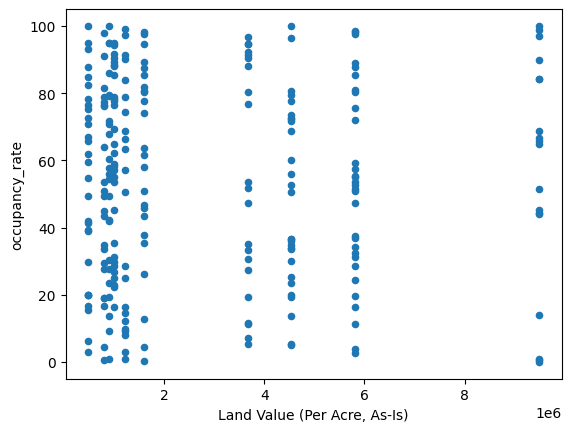

In [31]:
winter_2024.plot.scatter("Land Value (Per Acre, As-Is)", "occupancy_rate")

Occupancy rate ranges widely within each land value bracket. We will see how more categorical and numerical values relate to occupancy rate in PowerBI (hint: certain cities have higher land values and occupancy rates). 

## Note - Records at Max Occupancy

One of the questions I wanted to answer was how frequently certain shelters were at max occupancy. This question is only about the shelter dataset. I asked bearcatgpt to create code to answer this question and the results are provided below.

In [38]:
# Filter to max occupancy
max_occ = shelters[shelters["occupancy_rate"] == 100]

# 1) Count of days at 100% occupancy
count_by_shelter = max_occ.groupby("shelter_name").size().reset_index(name="days_at_100")

count_by_city = max_occ.groupby("City").size().reset_index(name="days_at_100")

# 2) Percentage of days at 100% occupancy
total_days_by_shelter = shelters.groupby("shelter_name").size().reset_index(name="total_days")

total_days_by_city = shelters.groupby("City").size().reset_index(name="total_days")

shelter_result = (
    count_by_shelter.merge(total_days_by_shelter, on="shelter_name", how="right").fillna({"days_at_100": 0})
)

shelter_result["pct_days_at_100"] = (
    shelter_result["days_at_100"] / result["total_days"] * 100
)

city_result = (
    count_by_city.merge(total_days_by_city, on="City", how="right").fillna({"days_at_100": 0})
)

city_result["pct_days_at_100"] = (
    city_result["days_at_100"] / result["total_days"] * 100
)

# Sort by shelters with the highest frequency of max occupancy
shelter_result = shelter_result.sort_values("pct_days_at_100", ascending=False)

city_result = city_result.sort_values("pct_days_at_100", ascending=False)

print(shelter_result.head(20))

         shelter_name  days_at_100  total_days  pct_days_at_100
8        Shelter Plus          3.0         109         2.752294
1            HomeSafe          2.0          98         2.040816
3      New Beginnings          2.0         117         1.709402
9     Sunrise Shelter          1.0         113         0.884956
0         Harbor Home          1.0         114         0.877193
2          Hope House          0.0         100         0.000000
5  Recovery Residence          0.0          95         0.000000
4       Pathway Place          0.0          89         0.000000
7       Second Chance          0.0          83         0.000000
6          Safe Haven          0.0          82         0.000000


In [39]:
print(city_result.head(20))

           City  days_at_100  total_days  pct_days_at_100
7   San Antonio          2.0         108         2.409639
9      San Jose          2.0          90         1.769912
6       Phoenix          1.0          82         1.219512
4      New York          1.0          94         1.123596
1        Dallas          1.0         101         1.020408
8     San Diego          1.0          97         0.917431
3   Los Angeles          1.0         116         0.854701
0       Chicago          0.0         115         0.000000
5  Philadelphia          0.0          93         0.000000
2       Houston          0.0         104         0.000000


## Next: PowerBI
To do further analysis and build an interactive dashboard in PowerBI we need to export the data as csv.

In [24]:
shelter_land_price.to_csv("shelter_land_price.csv")

In [41]:
shelter_result.to_csv("max_occupancy_rates_by_shelter.csv")

In [42]:
city_result.to_csv("max_occupancy_rates_by_city.csv")